<a href="https://colab.research.google.com/github/ParkHangah/AIFFEL_quest_eng/blob/master/LLM_Aplication/LLM02/BERT_PretraindeModel_VR2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BERT pretrainde model 제작**

## 0. 사전준비

### 0-1. Google 드라이브 연결

##### (1) 경로 설정

In [ ]:
# 드라이브 경로 설정  by 박항아
drive_path = '#Study/Aiffel/Work' # 평상시 작업하는 드라이브 폴더 경로를 입력해 주세요.
project_name = 'bert_pretrain'       # 이번 프로젝트세 사용하는 폴더명을 입력해주세요.

##### (2) 드라이브 연결

In [ ]:
from google.colab import drive
from IPython.display import clear_output
import os

# 1. 구글 드라이브 마운트
print("Connecting...")
drive.mount('/content/gdrive')

# 2. 경로 설정 및 폴더 생성
base_path = os.path.join('/content/gdrive/MyDrive',drive_path)
project_path = os.path.join(base_path, project_name)

# Create the project directory if it doesn't exist
os.makedirs(project_path, exist_ok=True)


# 2. 출력 전체 삭제 후 완료 메시지 출력
clear_output()
print("✅ 구글 드라이브 연결이 성공적으로 완료되었습니다.")
print(f"Selected Google Drive root path: {base_path}")

✅ 구글 드라이브 연결이 성공적으로 완료되었습니다.
Selected Google Drive root path: /content/gdrive/MyDrive/#Study/Aiffel/Work


### 0-2. 데이터 타운로드

In [ ]:
data_path = os.path.join(project_path, 'data')
model_path = os.path.join(project_path, 'models')

In [ ]:
# ! mkdir -p "{data_path}"
# ! mkdir -p "{model_path}"
# ! wget https://aiffelstaticprd.blob.core.windows.net/media/documents/kowiki.txt.zip
# ! mv kowiki.txt.zip "{data_path}"
# ! cd "{data_path}" && unzip kowiki.txt.zip


## 1. 라이브러리 설치

In [ ]:
#다음 라이브러리를 설치해주세요
!pip install sentencepiece
!pip install tqdm
!conda install -y -c conda-forge ipywidgets
!jupyter nbextension enable --py widgetsnbextension
!pip install torchsummary

/bin/bash: line 1: conda: command not found
Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


In [ ]:
# 파이썬 2와 3의 호환성을 위해 표준 라이브러리 기능들을 불러옴
from __future__ import absolute_import, division, print_function, unicode_literals

# --- PyTorch 관련 라이브러리 ---
import torch
import torch.nn as nn             # 신경망 레이어 (Linear, Conv2d 등)
import torch.nn.functional as F   # 활성화 함수 (ReLU, Softmax 등)
import torch.optim as optim       # 최적화 알고리즘 (Adam, SGD 등)
from torch.utils.data import DataLoader, TensorDataset    # 데이터셋 관리 및 미니배치 생성
from torchsummary import summary  # 모델의 구조와 파라미터 수를 요약

# --- 시스템 및 데이터 처리 라이브러리 ---
import os             # 디렉토리 경로 제어
import re             # 정규표현식을 이용한 텍스트 전처리
import math           # 수학 연산 (Log, Pi 등)
import numpy as np    # 수치 행렬 연산
import pandas as pd   # 데이터프레임 활용 (CSV, Excel 처리)
import random         # 무작위 추출 및 셔플
import collections    # Counter 등 특수 컨테이너 타입 활용
import json           # 설정 파일(Config) 읽기 및 쓰기
import shutil         # 파일 복사 및 이동
import zipfile        # 압축 파일 해제 및 관리
import copy           # 객체 깊은 복사(Deep Copy)
from datetime import datetime   # 학습 시간 기록 및 로그 생성

# --- 시각화 및 특수 도구 ---
import matplotlib.pyplot as plt   # 학습 곡선(Loss, Accuracy) 시각화
import sentencepiece as spm       # 구글의 서브워드 토크나이저 (NLP 핵심 도구)
from tqdm.notebook import tqdm    # 학습 진행 상황을 프로그레스 바로 표시

# --- 재현성을 위한 설정 ---
# 실험을 할 때마다 동일한 결과가 나오도록 랜덤 시드를 고정함
random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
# 참고: PyTorch의 경우 torch.manual_seed(random_seed)도 추가하는 것이 좋습니다.

# 현재 설치된 PyTorch 버전을 출력하여 환경 확인
print(torch.__version__)

2.8.0+cu126


In [ ]:
import matplotlib

print(torch.__version__)
print(np.__version__)
print(pd.__version__)
print(matplotlib.__version__)
print(json.__version__)
print(re.__version__)

2.8.0+cu126
2.0.2
2.2.2
3.10.0
2.0.9
2.2.1


## 2. Tokenizer 준비

GPT의 BPE, BERT의 WordPiece 모델 등의 성공으로
subword 기반의 토크나이징 기법이 주요한 방법론으로 굳어짐  
- SentencePiece 기반의 토크나이저 준비:
https://github.com/google/sentencepiece

※ 경로는 좌측 사이드 바에 폴더 아이콘을 눌러 해당 파일과 폴더를 찾은 후 경로복사를 해서 쓸 것

```
# 코드로 형식 지정됨
```



```
$ python
>>> import sentencepiece as spm
>>> import os
>>> corpus_file = '/content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/data/kowiki.txt'
>>> prefix = '/content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/models/ko_32000'
>>> vocab_size = 32000
>>> spm.SentencePieceTrainer.train(f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]")
```



In [ ]:
# ! python

In [ ]:
# # 모델 이동
# ! mv ko_32000.* '{model_path}'

In [ ]:
# data_dir = 'data'  # 드라이브 연결시 미리 했으므로 사용 X

# vocab loading
vocab = spm.SentencePieceProcessor()
vocab.load(f"{model_path}/ko_32000.model")

True

In [ ]:
#Q. 특수 token 7개를 제외한 나머지 token들을 출력해봅시다.
vocab_list = []
for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))
print(vocab_list)

['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다', '었다', '▁지', '▁수', '▁19', '▁가', '▁시', '▁20', '▁기', '▁전', '▁아', '▁하', '▁있다', '▁다', '▁제', '했다', '하였', '▁일', '▁한', '▁중', '▁정', '▁주', '하는', '▁것', '▁자', '▁공', '▁인', '되었다', '▁경', '▁위', '▁유', '▁보', '하고', '▁3', '▁등', '▁부', '하였다', '▁조', '하여', '▁미', '▁동', '▁선', '▁나', '으며', '▁모', '▁연', '▁영', '▁의', '▁오', '▁마', '에는', '▁발', '▁소', '한다', '▁고', '▁개', '▁201', '▁구', '▁세', '▁도', '▁상', '▁비', '▁스', '▁국', '▁서', '▁후', '▁여', '▁200', '▁때', '▁4', '▁성', '▁해', '▁관', '▁있는', '▁신', '▁프', '▁대한', '부터', '▁5', '00', '▁방', '▁또', '지만', '▁(', '▁역', '되어', '▁않', '▁만', '▁"', '▁장', '▁바', '까지', '▁무', '▁남', '▁통', '▁현', '▁교', '▁같', '에게', '▁내', '학교', '▁문', '▁출', '▁거', '▁포', '▁결', '된다', '▁《', '적인', '이라', '▁6', '▁우', '적으로', '▁불', '▁원', '▁최', '▁진', '▁생', '▁작', '▁어', '▁당', '국의', '▁노', '▁강', '▁알', '▁반', '▁7', '▁8', '▁계', '▁따', '▁파', '▁분', '▁없', '▁받', '▁말', '면서', '들이', 'or', '되었', '▁사용', "▁'", '▁두', '▁실', '에서는', '▁10', '▁리', '들은', '▁명', '▁함', '▁단', '▁이후', '하기', '▁예', '년에', '),',

In [ ]:
# [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print(tokens_org)

['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]']


## 3. 데이터 전처리

### 3-1. 데이터셋 불러오기

In [ ]:
pretrain_json_path = os.path.join(project_path, 'bert_pre_train.json')
# make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)

In [ ]:
# 라인수
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
total

862285

### 3-2. 데이터 검증

#### [데이터 SAMPLE]

{"tokens": ["[CLS]", "▁태어났다", ".", "▁조지아", "▁공과", "대학교를", "▁졸업하였다", ".", "▁그", "[MASK]", "▁해군에", "▁들어가", "▁전함", "·", "원자", "력", "·", "잠", "수", "함의", "▁승무", "원으로", "▁일하였다", ".", "▁1953", "년", "▁미국", "▁해군", "▁대", "위로", "▁예편", "하였고", "▁이후", "▁땅", "콩", "·", "면", "화", "▁등을", "▁가", "꿔", "▁많은", "▁돈을", "▁벌", "었다", ".", "▁그의", "▁별명이", "[MASK]", "[MASK]", "[MASK]", "▁농부", "\"", "▁(", "P", "ean", "ut", "[MASK]", "[MASK]", "[MASK]", "[MASK]", "[MASK]", "▁알려졌다", ".", "[SEP]", "▁셋", "▁기업", "[MASK]", "▁주", "▁상원", "▁의원", "▁선거에서", "▁낙선", "하나", "▁그", "▁선거가", "▁부정", "선거", "▁", "였", "음을", "▁입증", "하게", "▁되어", "▁당선", "되고", ",", "▁1966", "년", "▁조지아", "▁주", "▁지사", "▁선거에", "▁낙선", "하지만", "[MASK]", "[MASK]", "▁조지아", "▁주", "▁지", "사를", "▁역임했다", ".", "[MASK]", "▁되기", "▁전", "▁조지아", "주", "▁상원의", "원을", "▁두", "번", "▁연", "임", "했으며", ",", "▁1971", "년부터", "[MASK]", "[MASK]", "▁조지아", "▁지", "사로", "▁근무했다", ".", "▁조지아", "[MASK]", "[SEP]"], "segment": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], "is_next": 1, "mask_idx": [9, 48, 49, 50, 57, 58, 59, 60, 61, 65, 66, 67, 95, 96, 103, 118, 119, 126], "mask_label": ["▁후", "▁\"", "땅", "콩", "▁F", "ar", "mer", ")", "로", "▁1962", "년", "▁조지아", "▁1970", "년", "▁대통령이", "▁1975", "년까지", "▁주지"]}

#### 🔍 데이터셋 분석 결과

1. 🚨 치명적 오류: 토큰과 레이블의 불일치 (Alignment Error)
가장 심각한 문제입니다. tokens 리스트와 mask_label이 서로 다른 문장에서 온 것처럼 보입니다.

인덱스 65, 66, 67 부분을 보세요.

입력 토큰(tokens): ... [SEP](64), ▁셋(65), ▁기업(66), [MASK](67) ...

정답 레이블(mask_label): ... ▁1962(65), 년(66), ▁조지아(67) ...

분석: mask_idx가 65, 66번을 가리키고 있는데, 실제 tokens[65]에는 [MASK]가 아니라 **"▁셋"**이라는 엉뚱한 단어가 들어있습니다. 심지어 정답 레이블은 **"▁1962"**입니다.

결과: 모델은 입력으로 "셋"을 보고 있는데 정답은 "1962"라고 배우게 됩니다. 이건 모델에게 **"사과라고 쓰고 포도라고 읽어라"**라고 가르치는 것과 같습니다. 모델이 혼란에 빠져 학습을 포기(Loss 정체)하게 되는 근본 원인입니다.

2. 🧩 연속 마스킹(Consecutive Masking)의 난이도
mask_idx를 보면 [48, 49, 50], [57, 58, 59, 60, 61] 등 연속된 토큰들이 대거 마스킹되어 있습니다.

현상: Peanut Farmer 부분이 P, ean, ut, [MASK], [MASK], [MASK], [MASK], [MASK]로 처리되었습니다.

문제점: 주변 맥락이 하나도 없는 상태에서 5개 이상의 토큰을 연속으로 맞추는 것은 사전 학습 초기 모델에게 너무 가혹한 과제입니다. 보통은 무작위로 흩어져서 마스킹되어야 모델이 주변 단어를 보고 힌트를 얻을 수 있습니다.

3. ✅ 긍정적인 부분
특수 토큰: [CLS], [SEP], [MASK] 사용과 ▁(U+2581) 공백 토큰 처리는 아주 완벽합니다.

세그먼트: segment ID가 0과 1로 문장 경계에 맞춰 정확히 나뉘어 있습니다.

마스킹 비율: 128개 토큰 중 18개를 마스킹하여 약 14% 비중을 유지한 점은 정석적입니다.

🛠️ 해결을 위한 액션 플랜
현재 데이터 전처리 스크립트(가칭 create_pretraining_data.py)에서 마스킹 로직을 반드시 점검해야 합니다.

동기화 확인: tokens 리스트에 [MASK]를 치환하는 시점과 mask_label에 정답을 저장하는 시점의 인덱스가 어긋나지 않았는지 확인하세요.

치환 확인: mask_idx에 포함된 인덱스의 tokens는 무조건 [MASK](또는 10%의 확률로 랜덤 단어/원본 유지)로 바뀌어 있어야 합니다. 지금처럼 "▁셋"이 그대로 남아있는데 정답은 "▁1962"인 상황은 전처리 버그입니다.

랜덤성 강화: 마스킹할 인덱스를 뽑을 때 너무 연속되지 않도록 하거나, 전체 문장에서 골고루 뽑히도록 로직을 수정해 보세요.

#### 데이터셋 오류 수정 전략

* 데이터셋 json 파일 매우 크기 때문에 np.memmap을 사용해서 메모리 사용량을 최소화하는 전략
* 만들어진 json 파일을 라인 단위로 읽어 들여 np.memmap에 로딩할때 오류 개선 작업 진행  
* 하나의 데이터를 불러올때마다  
    1) [MASK]된 부분의 mask_idx 값을 리스트화 하고 길이 측정.  
    2) 측정된 길이가 기존 데이터 셋 정답리스트의 길이가 같은 지 비교  
    3) 마스크 갯수와 정답갯수가 불일치 함녀 해당 데이터는 불량 데이터로 삭제,이 실제 MASK된 부분의 갯수보다 많거나 적을 때는 해당 데이터는 삭제
    4) 길이가 같다면 실제 마스크의 mask_idx리스트와 데이터셋의 mask_id 리스트가 길이와 값이 일치한지 비교 후 다르면 실제 값으로 업데이트

#### 데이터셋 오류 수정 함수 정의

In [ ]:
import numpy as np
import json
import copy
from tqdm import tqdm

def build_bert_memmap_dataset(pretrain_json_path, vocab, n_seq=128, total_expected=None):
    """
    JSON 파일을 읽어 정제 후 np.memmap에 로딩하는 함수
    """
    # 1. 파일 전체 라인 수 확인 (tqdm 용도 및 초기 크기 할당)
    if total_expected is None:
        with open(pretrain_json_path, "r") as f:
            total_raw = sum(1 for _ in f)
    else:
        total_raw = total_expected

    # 2. np.memmap 파일 초기 생성 (넉넉하게 전체 크기로 할당)
    # 나중에 정제 후 남은 데이터만 슬라이싱해서 사용할 예정입니다.
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total_raw, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total_raw, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total_raw,))
    # MLM 레이블은 반드시 -1(ignore_index)로 초기화해야 합니다.
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total_raw, n_seq))
    labels_mlm[:] = -1

    valid_total = 0 # 정제를 통과한 실제 데이터 개수 카운트

    # 3. 라인 단위 처리
    with open(pretrain_json_path, "r") as f:
        for i, line in enumerate(tqdm(f, total=total_raw, desc="Cleaning & Mapping")):
            # 테스트를 위해 일부만 돌려보고 싶다면 아래 주석을 해제하세요.
            # if i > 1000: break

            data = json.loads(line)
            tokens = data["tokens"]
            mask_label_text = data["mask_label"]

            # --- [핵심 정제 로직 1: 실제 [MASK] 위치 강제 추출] ---
            # JSON의 mask_idx가 밀렸을 가능성이 높으므로, tokens 리스트에서 직접 [MASK]를 찾습니다.
            actual_mask_indices = [idx for idx, t in enumerate(tokens) if t == "[MASK]"]

            # --- [핵심 정제 로직 2: 개수 무결성 검사] ---
            # 실제 [MASK] 개수와 정답(mask_label)의 개수가 다르면 불량 데이터입니다.
            if len(actual_mask_indices) != len(mask_label_text):
                # print(f"⚠️ Skip index {i}: Mask mismatch ({len(actual_mask_indices)} vs {len(mask_label_text)})")
                continue

            # --- [데이터 변환 (유저님 기존 로직 통합)] ---

            # 1. encoder token ID 변환 및 패딩
            enc_token = [vocab.piece_to_id(p) for p in tokens]
            enc_token += [0] * (n_seq - len(enc_token))

            # 2. segment 패딩
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))

            # 3. nsp label
            label_nsp = data["is_next"]

            # 4. mlm label (정답 위치에만 ID를 넣고 나머지는 -1 유지)
            # 유저님의 기존 fill_value=0 보다 -1이 훨씬 학습에 유리합니다.
            label_mlm_row = np.full(n_seq, fill_value=-1, dtype=np.int32)
            for m_idx, m_label in zip(actual_mask_indices, mask_label_text):
                label_mlm_row[m_idx] = vocab.piece_to_id(m_label)

            # --- [memmap에 실제 데이터 쓰기] ---
            # 유효한(valid) 순서대로 차곡차곡 쌓습니다.
            enc_tokens[valid_total] = enc_token
            segments[valid_total] = segment
            labels_nsp[valid_total] = label_nsp
            labels_mlm[valid_total] = label_mlm_row

            valid_total += 1

    # 4. 플러시 및 최종 데이터 반환 (슬라이싱)
    enc_tokens.flush()
    segments.flush()
    labels_nsp.flush()
    labels_mlm.flush()

    print(f"\n✅ 완료: 총 {total_raw}개 중 {valid_total}개의 깨끗한 데이터를 로딩했습니다.")

    # 실제 데이터가 들어있는 부분만 잘라서 반환합니다.
    return (
        enc_tokens[:valid_total],
        segments[:valid_total],
        labels_nsp[:valid_total],
        labels_mlm[:valid_total],
        valid_total
    )



In [ ]:
# 실행
enc_tokens, segments, labels_nsp, labels_mlm, valid_total = build_bert_memmap_dataset(pretrain_json_path, vocab)

Cleaning & Mapping: 100%|██████████| 862285/862285 [00:52<00:00, 16480.47it/s]



✅ 완료: 총 862285개 중 228208개의 깨끗한 데이터를 로딩했습니다.


#### 8) prepare_train_val_split : 학습에 필요한 데이터를 로딩하는 함수 + 학습&검증데이터 분리(기존 load_pre_train_data 함수)

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

def prepare_train_val_split(enc_tokens, segments, labels_nsp, labels_mlm, valid_total, test_size=0.15):
    """
    정제된 memmap 데이터를 받아 Train/Validation 세트로 분할합니다.

    :param enc_tokens: encoder inputs (memmap 슬라이스)
    :param segments: segment inputs (memmap 슬라이스)
    :param labels_nsp: nsp labels (memmap 슬라이스)
    :param labels_mlm: mlm labels (memmap 슬라이스)
    :param valid_total: 정제 완료된 유효 데이터의 총 개수
    :param test_size: 검증 데이터 비율 (기본 15%)
    :return train_data: (inputs, labels) 튜플 형태의 학습 데이터
    :return val_data: (inputs, labels) 튜플 형태의 검증 데이터
    """

    # 1. 유효 데이터 범위 내의 인덱스 생성
    # build_bert_memmap_dataset에서 반환된 valid_total을 기준으로 합니다.
    indices = np.arange(valid_total)

    # 2. Train / Validation 인덱스 분할
    # 데이터를 직접 복사하지 않고 인덱스만 나누어 메모리 효율을 극대화합니다.
    train_idx, val_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=42,
        shuffle=True
    )

    # 3. 분할된 데이터 구조화 (기존 유저의 튜플 구조 유지)
    # 튜플 구조: ((enc_input, segment_input), (nsp_label, mlm_label))
    train_data = (
        (enc_tokens[train_idx], segments[train_idx]),
        (labels_nsp[train_idx], labels_mlm[train_idx])
    )

    val_data = (
        (enc_tokens[val_idx], segments[val_idx]),
        (labels_nsp[val_idx], labels_mlm[val_idx])
    )

    print(f"📊 데이터 분할 완료")
    print(f"   - 전체 유효 데이터: {valid_total}개")
    print(f"   - 학습 데이터(Train): {len(train_idx)}개")
    print(f"   - 검증 데이터(Val)  : {len(val_idx)}개")

    return train_data, val_data

In [ ]:
train_data, val_data = prepare_train_val_split(enc_tokens, segments, labels_nsp, labels_mlm, valid_total)
pre_train_inputs, pre_train_labels = train_data
pre_val_inputs, pre_val_labels = val_data

📊 데이터 분할 완료
   - 전체 유효 데이터: 228208개
   - 학습 데이터(Train): 193976개
   - 검증 데이터(Val)  : 34232개


In [ ]:
# 처음과 마지막 확인
pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]

(array([    5,  2244,  9052, 12146,  3310,   506,  3949,   231,  8477,
         2682,  2835, 12156, 27624,  6808,  1461,   421,  2696,     6,
        11782,     6,     6,  7467, 27740, 27794,  1443,  4752,  1495,
          152,  7383,     8, 11434,     6,     6,     6,   346, 27644,
            6,     6,  5542,    50,   493, 11631,   277,  3338,     6,
            6,  2696,  3030, 27644,  1461, 27601,   619, 27946,  1285,
          231,     6,     6,     6,     6, 26055,  1325, 27970, 27737,
           30, 27619, 27621, 16217, 16860,   345, 27599,  4247,   169,
         3882,  1461,    35, 23287,     6,  3149,  5805,  4229, 27599,
            4,   714, 27625,  6812, 17808, 10994, 14687,  6820,   660,
         9986,   432,   608,   776, 27625, 18309,  3857,  8823, 19973,
        27628,  6820,   320,  6654, 27599,     4,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
      

In [ ]:
# 처음과 마지막 확인
pre_val_inputs[0][0], pre_val_inputs[0][-1], pre_val_inputs[1][0], pre_val_inputs[1][-1], pre_val_labels[0][0], pre_val_labels[0][-1], pre_val_labels[1][0], pre_val_labels[1][-1]

(array([    5,   109, 27744,  1093, 28076,     4,   109, 27744,  1093,
        28076, 27617, 28454,     1, 31561, 28800, 29927, 27616, 27613,
         2566,     6,     6,     6,     6,   130, 27959, 27606,   518,
           28, 27599,   629, 27625,    49, 27662,     6,     6,  5310,
         1086,   657,  7652,    30,  2598,  1354,  1517, 27599,     4,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
      

## 4. BERT 모델 구현

### 4-1. 유틸리티 함수를 정의

In [ ]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

print("슝=3")

슝=3


In [ ]:
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

print("슝=3")

슝=3


In [ ]:
def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_

def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_

print("슝=3")

슝=3


In [ ]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)
print("슝=3")

슝=3


### 4-2. Token Embedding의 구현

In [ ]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)

        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs
print("슝=3")

슝=3


### 4-3. Position Embedding 레이어

In [ ]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

print("슝=3")

슝=3


### 4-4. ScaleDotProductAttention과 이를 활용한 MultiHeadAttention

In [ ]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

print("슝=3")

슝=3


In [ ]:
# Q. 주석과 코드를 참조하여 아래 클래스를 완성해주세요.
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out
print("슝=3")

슝=3


### 4-5. transformer encoder 레이어

In [ ]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

print("슝=3")

슝=3


In [ ]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

print("슝=3")

슝=3


### 4-6. BERT 레이어

In [ ]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

print("슝=3")

슝=3


### 4-7. pretrain용 BERT 모델 구성

In [ ]:
# Encoder Layer class 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: softmax된 결과
        """
        outputs = F.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        outputs = F.softmax(outputs, dim=-1)
        return outputs

print("슝=3")

슝=3


In [ ]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        logits_cls = self.pooled_output(logits_cls)
        outputs_nsp = F.softmax(logits_cls, dim=-1)

        outputs_mlm = F.softmax(logits_lm, dim=-1)
        return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

print("슝=3")

슝=3


## 5. pretrain 객체

### 5-0. config

In [ ]:
# 모델 파일 경로 (예: ko_8000.model)
spp = spm.SentencePieceProcessor()
spp.load(f"{data_path}/ko_8000.model")

True

In [ ]:
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

config = Config({
    "d_model": 128,          # 내부 표현 차원
    "n_head": 4,             # 멀티 헤드 어텐션 개수
    "d_head": 32,            # [수정] d_model / n_head = 32 (표준 비율)
    "dropout": 0.1,
    "d_ff": 512,             # [수정] 보통 d_model의 4배인 512를 권장 (1024는 너무 큼)
    "layernorm_epsilon": 1e-12, # [수정] BERT 표준값
    "n_layer": 3,            # 학습 속도를 위해 3~6층 유지 권장
    "n_seq": 128,            # [수정] 유저님의 데이터 정제 규격(128)과 일치시켜야 함
    "n_vocab": len(spp),   # 32,000 (동기화 완료)
    "i_pad": spp.pad_id()  # 패딩 ID (보통 0)
})

class Vocab:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.pad_id = 0

vocab = Vocab(config.n_vocab)
config.n_vocab = vocab.vocab_size
config.i_pad = vocab.pad_id

In [ ]:
# 실제 데이터 규격에 맞춘 테스트 데이터 생성
n_test_data = 10
n_seq = config.n_seq # 128

# 1. 입력 토큰들
enc_tokens = torch.randint(0, config.n_vocab, (n_test_data, n_seq))
segments = torch.randint(0, 2, (n_test_data, n_seq))
labels_nsp = torch.randint(0, 2, (n_test_data,))

# 2. [핵심] MLM 레이블 (대부분 -1로 채우고 일부만 정답 부여)
labels_mlm = torch.full((n_test_data, n_seq), fill_value=-1, dtype=torch.long)
for i in range(n_test_data):
    # 각 문장당 15% 정도(약 19개)만 마스킹 정답 부여
    mask_indices = random.sample(range(n_seq), int(n_seq * 0.15))
    labels_mlm[i, mask_indices] = torch.randint(0, config.n_vocab, (len(mask_indices),))

# 데이터로더 생성
batch_size = 64
train_dataset = TensorDataset(enc_tokens, segments, labels_nsp, labels_mlm)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

### 5-1. loss와 accuracy같이 기본적으로 필요한 계산 함수를 미리 정의

In [ ]:
def lm_loss(y_true, y_pred):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # loss 계산
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    loss = loss * mask
    return loss.mean() * 20   # mlm을 더 잘 학습하도록 20배 증가 시킴

print("슝=3")

슝=3


In [ ]:
def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # 정답 여부 확인
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    matches *= mask
    # 정확도 계산
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

print("슝=3")

슝=3


### 5-2. Learning Rate 스케줄링

In [ ]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        return self.get_lr()

print("슝=3")

슝=3


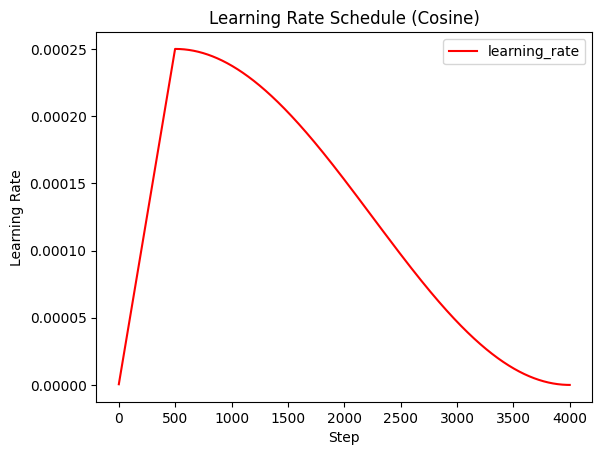

In [ ]:
# compute lr
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

### 5-3. 모델을 실제로 빌드해보기

In [ ]:
# 모델 생성을 위한 라이브러리 설치
!pip install torchinfo

In [ ]:
# 모델 생성
from torchinfo import summary
# config 수정 예시 (모델 생성 전 실행)
config.n_vocab = 32007
config.n_seq = 128
pre_train_model = build_model_pre_train(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 128]                 --
│    └─SharedEmbedding: 2-1                                  [10, 128, 128]            4,096,896
│    └─PositionEmbedding: 2-2                                [10, 128, 128]            --
│    │    └─Embedding: 3-1                                   [10, 128, 128]            16,384
│    └─Embedding: 2-3                                        [10, 128, 128]            256
│    └─LayerNorm: 2-4                                        [10, 128, 128]            256
│    └─Dropout: 2-5                                          [10, 128, 128]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 128]       

###5-4. 텐서변환 및 데이터로더 설정 및 히스토리 초기화

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU가 있으면 cuda 사용, 없으면 CPU

# x가 텐서인지 확인하고, 텐서라면 cpu로 옮긴 뒤 numpy로 변환하거나 바로 텐서 처리를 합니다.
def to_tensor(x, device):
    if torch.is_tensor(x):
        return x.to(device) # 이미 텐서라면 장치만 이동
    else:
        return torch.tensor(np.array(x)).to(device) # 넘파이 배열이라면 텐서로 변환 후 이동

# 1. 학습 데이터 텐서 변환 및 DataLoader 생성
pre_train_inputs = [to_tensor(x, device) for x in pre_train_inputs]
pre_train_labels = [to_tensor(x, device) for x in pre_train_labels]
train_dataset = TensorDataset(pre_train_inputs[0], pre_train_inputs[1], pre_train_labels[0], pre_train_labels[1])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 2. 검증 데이터 텐서 변환 및 DataLoader 생성
val_enc_tokens = to_tensor(pre_val_inputs[0], device)
val_segments = to_tensor(pre_val_inputs[1], device)
val_labels_nsp = to_tensor(pre_val_labels[0], device)
val_labels_mlm = to_tensor(pre_val_labels[1], device)
val_dataset = TensorDataset(
    val_enc_tokens,
    val_segments,
    val_labels_nsp,
    val_labels_mlm
)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

pre_train_model.to(device)

history = {
    'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': [],
    'val_nsp_loss': [], 'val_mlm_loss': [], 'val_nsp_acc': [], 'val_mlm_acc': [] # 검증용 추가
}

### 5-5. BERTTrainer - train loop 객체화

In [ ]:
class BERTTrainer:
    def __init__(self, model, train_loader, val_loader, optimizer, loss_fns, config, device, scheduler=None, history=None):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = optimizer
        self.loss_fn_nsp = loss_fns['nsp']
        self.loss_fn_mlm = loss_fns['mlm']
        self.config = config
        self.device = device
        self.scheduler = scheduler

        # 최적의 Loss를 추적하기 위한 변수 (초기값은 무한대)
        self.best_val_loss = float('inf')

        # 만약 기존 history가 있으면 그것을 사용하고, 없으면 새로 만듭니다.
        if history is not None:
            self.history = history
        else:
            self.history = {
                'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': [],
                'val_nsp_loss': [], 'val_mlm_loss': [], 'val_nsp_acc': [], 'val_mlm_acc': []
            }

    def train(self, epochs, start_epoch=0, save_path="./"):
        if not os.path.exists(save_path):
            os.makedirs(save_path)

        # 히스토리 파일 경로 설정
        history_file = os.path.join(save_path, "history.json")

        for epoch in range(start_epoch, start_epoch + epochs):
            # --- [TRAIN 단계] ---
            self.model.train()
            train_results = self._run_epoch(self.train_loader, training=True)

            # 결과 저장 (Train)
            self.history['nsp_loss'].append(train_results['nsp_loss'])
            self.history['mlm_loss'].append(train_results['mlm_loss'])
            self.history['nsp_acc'].append(train_results['nsp_acc'])
            self.history['mlm_acc'].append(train_results['mlm_acc'])

            # --- [VALIDATION 단계] ---
            self.model.eval()
            with torch.no_grad():
                val_results = self._run_epoch(self.val_loader, training=False)

            # 결과 저장 (Val)
            self.history['val_nsp_loss'].append(val_results['nsp_loss'])
            self.history['val_mlm_loss'].append(val_results['mlm_loss'])
            self.history['val_nsp_acc'].append(val_results['nsp_acc'])
            self.history['val_mlm_acc'].append(val_results['mlm_acc'])

            # 현재 에폭의 전체 Validation Loss 계산
            current_val_loss = val_results['nsp_loss'] + val_results['mlm_loss']

            # 에폭 결과 출력
            self._print_log(epoch, start_epoch + epochs)

            test_results = test_bert_sentences(
                model=pre_train_model,
                tokenizer=spp,
                device=device,
                sentences=test_sentences[:2],
                top_k=3  # 상위 5개 결과 출력
            )

            # --- [1. 히스토리 파일 업데이트] ---
            # 매 에폭마다 호출되어 최신 정보를 저장합니다.
            with open(history_file, 'w') as f:
                json.dump(self.history, f, indent=4)
            print(f"  📊 History updated: {history_file}")

            # --- [2. 모델 체크포인트 저장 로직] ---
            # 1. 첫 번째 에폭일 때 저장
            # 2. 현재 Validation Loss가 역대 최저일 때 저장 (Best Model)
            is_best = current_val_loss < self.best_val_loss
            save_file = f"{save_path}/bert_pre_train_epoch_{epoch+1}.pt"
            # 모델 저장
            if (epoch == start_epoch) or is_best:
                if is_best:
                    self.best_val_loss = current_val_loss
                    print(f"✨ New Best Model Found! (Loss: {current_val_loss:.4f})")
                save_file = f"{save_path}/bert_pre_train_epoch_{epoch+1}_loss_{current_val_loss:.4f}.pt"
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'loss': current_val_loss,
                    'history': self.history
                }, save_file)
                print(f"💾 Checkpoint saved: {save_file}")

    def _run_epoch(self, dataloader, training=True):
        """한 에폭 동안 배치를 돌며 연산하는 내부 메서드"""
        total_nsp_loss, total_mlm_loss = 0, 0
        total_nsp_acc, total_mlm_acc = 0, 0

        for batch in dataloader:
            enc_tokens, segments, labels_nsp, labels_mlm = batch

            if training:
                self.optimizer.zero_grad()

            logits_nsp, logits_mlm = self.model(enc_tokens, segments)

            # 정답 데이터 정제
            labels_nsp = labels_nsp.long()
            # [수정] clamp(0, ...)를 제거합니다. -1을 0으로 바꾸면 모델이 마스킹되지 않은 일반 단어까지
            # 특정 토큰(보통 [PAD])으로 예측하도록 잘못 학습되어 Loss가 줄어들지 않습니다.
            # labels_mlm = labels_mlm.clamp(0, self.config.n_vocab - 1).long() # 기존코드
            labels_mlm = labels_mlm.long()

            # Loss 계산
            loss_nsp = self.loss_fn_nsp(logits_nsp, labels_nsp)
            # ignore_index=-1 설정에 의해 labels_mlm의 -1 값들은 자동으로 Loss 계산에서 제외됩니다.
            loss_mlm = self.loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm.view(-1))
            loss = loss_nsp + loss_mlm

            if training:
                loss.backward()
                # 그래디언트 폭주 방지를 위해 클리핑 추가 (권장)
                # self.optimizer.step() # 기존코드
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()
                if hasattr(self, 'scheduler') and self.scheduler is not None:
                    self.scheduler.step()
                self.optimizer.zero_grad()

            # 통계합산
            total_nsp_loss += loss_nsp.item()
            total_mlm_loss += loss_mlm.item()

            # NSP 정확도: 이진 분류이므로 전체 평균 계산
            total_nsp_acc += (logits_nsp.argmax(dim=-1) == labels_nsp).float().mean().item()
            # [수정] MLM 정확도: "진짜 실력" 측정
            # total_mlm_acc += (logits_mlm.argmax(dim=-1) == labels_mlm).float().mean().item() #기존코드
            # 1. 모델의 예측값 추출
            preds_mlm = logits_mlm.argmax(dim=-1)
            # 2. 마스킹된 위치(레이블이 -1이 아닌 곳)만 찾아내는 마스크 생성
            mask_mlm = (labels_mlm != -1)
            # 3. 마스킹된 위치에서만 정답 여부 확인
            correct_mlm = (preds_mlm == labels_mlm) & mask_mlm
            # 4. (맞춘 개수 / 실제 마스크 개수)로 계산하여 진짜 정확도 산출
            # 마스크가 하나도 없는 배치일 경우를 대비해 max(1, ...) 처리를 합니다.
            actual_mask_count = mask_mlm.sum().item()
            batch_mlm_acc = correct_mlm.sum().item() / max(1, actual_mask_count)
            total_mlm_acc += batch_mlm_acc

        count = len(dataloader)
        return {
            'nsp_loss': total_nsp_loss / count,
            'mlm_loss': total_mlm_loss / count,
            'nsp_acc': total_nsp_acc / count,
            'mlm_acc': total_mlm_acc / count
        }

    def _print_log(self, epoch, total_epochs):
        print(f"Epoch {epoch+1}/{total_epochs}")
        print(f"  Train -> Loss: {self.history['nsp_loss'][-1] + self.history['mlm_loss'][-1]:.4f}, "
              f"NSP Acc: {self.history['nsp_acc'][-1]:.4f}, MLM Acc: {self.history['mlm_acc'][-1]:.4f}")
        print(f"  Val   -> Loss: {self.history['val_nsp_loss'][-1] + self.history['val_mlm_loss'][-1]:.4f}, "
              f"NSP Acc: {self.history['val_nsp_acc'][-1]:.4f}, MLM Acc: {self.history['val_mlm_acc'][-1]:.4f}")

### 5-6. 시각화 코드 클래스화

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class BERTVisualizer:
    def __init__(self, history):
        self.history = history

    def plot_loss(self):
        plt.figure(figsize=(15, 5))

        # 1. NSP Loss 그래프
        plt.subplot(1, 2, 1)
        self._draw_loss_plot(
            self.history['nsp_loss'],
            self.history['val_nsp_loss'],
            'NSP Loss'
        )

        # 2. MLM Loss 그래프
        plt.subplot(1, 2, 2)
        self._draw_loss_plot(
            self.history['mlm_loss'],
            self.history['val_mlm_loss'],
            'MLM Loss'
        )

        plt.tight_layout()
        plt.show()

    def _draw_loss_plot(self, train_loss, val_loss, title):
        epochs = range(1, len(train_loss) + 1)

        # 기본 선 그래프
        plt.plot(epochs, train_loss, 'b--', label=f'Train {title}', alpha=0.6)
        plt.plot(epochs, val_loss, 'r-', label=f'Val {title}', linewidth=2)

        # 최저점 찾기 (Validation Loss 기준)
        min_val_loss = min(val_loss)
        min_epoch = val_loss.index(min_val_loss) + 1

        # 최저점에 별 표시 (★)
        plt.scatter(min_epoch, min_val_loss, color='red', marker='*', s=200,
                    label=f'Best (Ep:{min_epoch})', zorder=5)

        # 주석 추가 (숫자 표시)
        plt.annotate(f'{min_val_loss:.4f}',
                     xy=(min_epoch, min_val_loss),
                     xytext=(min_epoch, min_val_loss + (max(val_loss)-min_val_loss)*0.1),
                     ha='center', fontsize=10, color='red',
                     arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5))

        plt.title(title, fontsize=14)
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.legend()

## 6. 모델 개선 방향 및 테스트 함수 설정

### 6-1. 모델 개선 방향

##### (1) 학습률(Learning Rate) 및 스케줄링

학습률은 모델 학습에서 가장 중요한 변수입니다. 너무 높으면 손실(Loss)이 발산하고, 너무 낮으면 학습 속도가 지나치게 느려지거나 국소 최적점(Local Minimum)에 갇힐 수 있습니다.
- 학습률 범위: BERT 계열의 대규모 사전 학습에서는 보통 $2 \times 10^{-5}$에서 $5 \times 10^{-5}$ 사이의 작은 값을 권장합니다.
- 웜업(Warmup) 비율: 학습 초기에는 무작위 가중치로 인해 그래디언트가 불안정하므로, 전체 스텝의 5~10% 정도는 아주 작은 학습률에서 목표치까지 서서히 올리는 웜업 구간을 설정하는 것이 좋습니다.
- 코사인 감쇠(Cosine Decay): 웜업 이후 학습률을 고정하기보다 코사인 곡선을 그리며 서서히 낮추면, 학습 후반부에 가중치를 더 정교하게 미세 조정하여 더 낮은 손실 값에 도달할 수 있습니다.

##### (2) 배치 크기(Batch Size) 및 그래디언트 누적

배치 크기는 모델이 가중치를 한 번 업데이트할 때 보는 데이터의 양을 결정하며, 학습의 안정성과 직접적으로 연관됩니다.
- 대형 배치의 장점: 배치 크기가 클수록 그래디언트의 분산이 줄어들어 학습이 안정화됩니다. 하드웨어 메모리가 허용하는 한 최대한 크게(예: 32, 64 이상) 설정하는 것이 유리합니다.
- 그래디언트 누적(Gradient Accumulation): 메모리 한계로 큰 배치를 쓸 수 없다면, 여러 번의 배치를 실행한 뒤 한 번에 업데이트하는 방식을 통해 가상의 큰 배치 효과를 낼 수 있습니다.

##### (3) 그래디언트 클리핑(Gradient Clipping)

트랜스포머 구조에서는 그래디언트가 갑자기 커지는 '그래디언트 폭주(Exploding Gradients)' 현상이 발생할 수 있습니다.
- Max Norm 설정: 그래디언트의 노름(Norm)이 일정 임계값(보통 1.0)을 넘지 않도록 강제로 제한합니다. 이는 학습 도중 Loss가 갑자기 NaN이 되거나 튀는 현상을 방지하여 학습의 안정성을 획기적으로 높여줍니다.

##### (4) 가중치 감쇠(Weight Decay) 및 규제

모델이 학습 데이터에만 너무 치중되어 과적합(Overfitting)되는 것을 막기 위한 파라미터입니다.
- AdamW 옵티마이저: 단순한 Adam보다는 L2 규제가 옵티마이저 단계에서 분리된 AdamW를 사용하고, weight_decay 값을 0.01 정도로 설정하여 모델의 일반화 성능을 높입니다.
- 드롭아웃(Dropout): 레이어 사이의 연결을 무작위로 끊는 드롭아웃 비율을 0.1 정도로 유지하여 특정 뉴런에만 의존하지 않도록 만듭니다.

##### (5) 마스킹 전략(Masking Strategy) 조정

사전 학습 작업인 MLM(Masked Language Modeling)의 난이도를 조절하는 변수입니다.
- 마스킹 비율: 표준은 **15%**이지만, 데이터셋이 매우 크거나 복잡하다면 비율을 조금 높여 모델이 더 강력한 문맥 이해력을 갖추도록 유도할 수 있습니다.
- Whole Word Masking: 형태소나 단어의 일부가 아닌 단어 전체를 마스킹하면 주변 문맥을 파악하는 능력이 더욱 향상됩니다.

### 6-2. BERT 학습 모델 성능 테스트

#### 1) BERT 모델 테스트를 위한 함수 선언

In [ ]:
import torch

def test_bert_sentences(model, tokenizer, device, sentences, top_k=5):
    """
    리스트로 된 테스트 문장들을 받아 BERT 모델의 예측 결과를 출력하는 함수
    :param sentences: ['오늘 날씨가 __ 좋다', '파이썬은 __ 언어다'] 형태의 리스트
    """
    model.eval()
    # 토크나이저의 실제 유효 범위 확인
    vocab_size = len(tokenizer)
    results = []

    print(f"✅ 총 {len(sentences)}개의 문장에 대한 예측을 시작합니다.\n")

    for idx, user_input in enumerate(sentences):
        print(f"📝 테스트 {idx+1}: {user_input}")

        # 1. '__'를 '[MASK]'로 치환
        processed_input = user_input.replace("__", "[MASK]")

        if "[MASK]" not in processed_input:
            print("   ⚠️ 경고: 문장에 '__'가 포함되어 있지 않습니다. 건너뜁니다.")
            continue

        try:
            # 2. 토큰화 및 특수 토큰 추가
            pieces = tokenizer.encode_as_pieces(processed_input)
            tokens = ["[CLS]"] + pieces + ["[SEP]"]

            # 3. [MASK] 토큰 위치 찾기
            if "[MASK]" not in tokens:
                print("   ⚠️ 경고: 토큰화 과정에서 마스크가 인식되지 않았습니다. '__' 앞뒤에 공백을 추가해 보세요.")
                continue

            mask_idx = tokens.index("[MASK]")

            # 4. ID 변환 및 텐서 생성
            input_ids = torch.tensor([[tokenizer.piece_to_id(p) for p in tokens]]).to(device)
            segment_ids = torch.tensor([[0] * len(tokens)]).to(device)

            # 5. 모델 추론
            with torch.no_grad():
                # BERT 모델은 보통 (NSP_logits, MLM_logits)를 반환합니다.
                _, logits_lm = model(input_ids, segment_ids)

                # 마스크 위치의 로짓(Logits) 추출 및 확률 계산
                mask_logits = logits_lm[0, mask_idx]
                probs = torch.softmax(mask_logits, dim=-1)

                # 상위 K개 결과 추출
                topk_prob, topk_indices = torch.topk(probs, top_k)

            # 6. 결과 출력
            print("   💡 예측 결과:")
            current_results = []
            for i, (tid, prob) in enumerate(zip(topk_indices, topk_prob)):
                tid_int = int(tid)
                word = tokenizer.id_to_piece(tid_int )
                # [수정 포인트] ID가 토크나이저 범위를 벗어나는지 확인
                if 0 <= tid_int < vocab_size:
                    word = tokenizer.id_to_piece(tid_int)
                else:
                    # 범위를 벗어난 경우 특수 토큰이거나 잘못된 예측
                    word = f"[Unknown_ID_{tid_int}]"
                confidence = prob.item() * 100
                print(f"      {i+1}순위: {word} ({confidence:.2f}%)")
                current_results.append((word, confidence))

            results.append({"sentence": user_input, "predictions": current_results})
            print("-" * 30)

        except Exception as e:
            print(f"   ❌ 에러 발생: {e}")

    return results

#### 2) BERT 모델 TEST를 위한 문장 LIST

In [ ]:
# 1. 테스트 문장 리스트 선언 (난이도별/분야별)
test_sentences = [
    # 기초 문맥
    "오늘 날씨가 너무 __ 좋아서 산책을 갔다",
    "배가 너무 고파서 식당에서 __를 주문했다",
    "비가 갑자기 내려서 급하게 __를 썼다",

    # IT/학습 지식
    "파이썬은 데이터 __ 분야에서 가장 인기가 많다",
    "트랜스포머 모델의 핵심 기술은 __ 메커니즘이다",

    # 역사/관용구
    "세종대왕은 백성을 위해 __를 창제하셨다",
    "가는 말이 고와야 __ 말이 곱다"
]


## 7. PreTrain 진행

### 학습안되는 문제 해결: 모델 구조 및 코드 방면

In [ ]:
# train_dataloader에서 샘플 하나를 꺼내 확인합니다.
sample_batch = next(iter(train_dataloader))
input_ids = sample_batch[0] # 첫 번째 문장 텐서
labels_mlm = sample_batch[3] # MLM 정답 텐서

print(f"현재 [MASK]의 ID: {spp.piece_to_id('[MASK]')}")
print(f"실제 입력 데이터에 [MASK] ID가 포함되어 있는가?: {(input_ids == spp.piece_to_id('[MASK]')).any()}")
print(f"학습할 레이블(-1이 아닌 값)이 존재하는가?: {(labels_mlm != -1).any()}")

현재 [MASK]의 ID: 6
실제 입력 데이터에 [MASK] ID가 포함되어 있는가?: True
학습할 레이블(-1이 아닌 값)이 존재하는가?: True


In [ ]:
if 'id' in locals() and isinstance(id, int):
    del id
    print("✅ 변수 'id'를 삭제하여 기본 함수 id()를 복구했습니다.")

✅ 변수 'id'를 삭제하여 기본 함수 id()를 복구했습니다.


In [ ]:
import torch
import torch.optim as optim
import ctypes # id() 함수가 망가졌을 때를 대비한 대체 수단

# 테스트용 코드: 데이터 타입을 Long으로 강제 변환하여 실행
# 1. 모델과 옵티마이저 재연결 (중요!)
pre_train_model.to(device)
pre_train_model.train()
# 현재 모델의 파라미터를 직접 주입하여 옵티마이저를 새로 생성합니다.
# 테스트를 위해 학습률을 1e-3(0.001)으로 높게 설정했습니다.
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-3)
# 2. 메모리 주소 동기화 체크
model_addr = id(next(pre_train_model.parameters()))
optim_addr = id(optimizer.param_groups[0]['params'][0])

print(f"📍 모델 가중치 주소: {model_addr}")
print(f"📍 옵티마이저 관리 주소: {optim_addr}")
print(f"🔗 주소 일치 여부: {model_addr == optim_addr}")

one_batch = next(iter(train_dataloader))
input_ids, segment_ids, labels_nsp, labels_mlm = [x.to(device) for x in one_batch]
print("🚀 1개 배치 과적합 테스트 시작...")

for i in range(50):
    optimizer.zero_grad()
    logits_nsp, logits_mlm = pre_train_model(input_ids, segment_ids)

    # [수정] .long()을 추가하여 자료형을 맞춥니다.
    loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp.long())
    loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm.view(-1).long())
    loss = loss_nsp + loss_mlm

    loss.backward()

    # 모든 파라미터 중 그래디언트가 0이 아닌 것이 하나라도 있는지 확인
    has_grad = False
    for name, param in pre_train_model.named_parameters():
        if param.grad is not None:
            if param.grad.abs().sum() > 0:
                has_grad = True
                break

    print(f"🤔 그래디언트가 생성되었는가?: {has_grad}")
    optimizer.step()

    if i % 10 == 0:
        # 이 수치가 10.6에서 아래로 떨어지는지 확인하는 것이 핵심입니다!
        print(f"Iteration {i:2d}, Total Loss: {loss.item():.4f} (NSP: {loss_nsp.item():.4f}, MLM: {loss_mlm.item():.4f})")

print("✅ 테스트 종료")

📍 모델 가중치 주소: 132883302334544
📍 옵티마이저 관리 주소: 132883302334544
🔗 주소 일치 여부: True
🚀 1개 배치 과적합 테스트 시작...
🤔 그래디언트가 생성되었는가?: True
Iteration  0, Total Loss: 10.9564 (NSP: 0.5828, MLM: 10.3736)
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
Iteration 10, Total Loss: 11.0316 (NSP: 0.6598, MLM: 10.3718)
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
Iteration 20, Total Loss: 10.9776 (NSP: 0.6129, MLM: 10.3647)
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
🤔 그래디언트가 생성되었는가?: True
It

### 7-0. Baseline: epochs = 10, batch_size = 64, lr=5e-5

#### 1) 기본

In [ ]:
epochs = 10
batch_size = 64
# 1. 모델 준비 (이미 되어있다면 패스)
pre_train_model.to(device)
pre_train_model.train()

# 2. 옵티마이저 재선언 (실제 학습용 LR 적용)
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4, weight_decay=0.01)
# 3. 스케줄러 설정 (데이터 정제 결과인 valid_total 반영)
# [수정] 기존 pre_train_inputs[0] 대신 정제된 데이터 개수인 valid_total을 사용하세요.
steps_per_epoch = math.ceil(valid_total / batch_size)
total_train_steps = steps_per_epoch * epochs

print(f"📊 학습 정보 확인:")
print(f"   - 총 데이터 개수: {valid_total}")
print(f"   - 에폭당 스텝 수: {steps_per_epoch}")
print(f"   - 전체 학습 스텝: {total_train_steps}")

# 워밍업 스텝은 보통 전체의 10% 정도로 잡습니다.
learning_rate_scheduler = CosineSchedule(
    train_steps=total_train_steps,
    warmup_steps=max(100, total_train_steps // 10)
)

# 4. 손실 함수 설정
loss_fn_nsp = nn.CrossEntropyLoss()
criterion_mlm = nn.CrossEntropyLoss(ignore_index=-1)
loss_fns = {'nsp': loss_fn_nsp, 'mlm': criterion_mlm}

# 5. 트레이너 초기화
trainer = BERTTrainer(
    model=pre_train_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    loss_fns=loss_fns,
    config=config,
    device=device,
    scheduler=learning_rate_scheduler
)

# 6. 학습 시작
# 만약 이전에 중단된 지점부터 이어서 하려면 start_epoch를 조절하세요.
trainer.train(epochs=epochs, save_path=f"{project_path}/work")

📊 학습 정보 확인:
   - 총 데이터 개수: 228208
   - 에폭당 스텝 수: 3566
   - 전체 학습 스텝: 35660
Epoch 1/10
  Train -> Loss: 10.9454, NSP Acc: 0.8220, MLM Acc: 0.0047
  Val   -> Loss: 10.9436, NSP Acc: 0.8199, MLM Acc: 0.0059
✅ 총 2개의 문장에 대한 예측을 시작합니다.

📝 테스트 1: 오늘 날씨가 너무 __ 좋아서 산책을 갔다
   💡 예측 결과:
      1순위: 리그 (0.00%)
      2순위: ▁코 (0.00%)
      3순위: ▁이후 (0.00%)
------------------------------
📝 테스트 2: 배가 너무 고파서 식당에서 __를 주문했다
   💡 예측 결과:
      1순위: 리그 (0.00%)
      2순위: ▁코 (0.00%)
      3순위: ▁이후 (0.00%)
------------------------------
  📊 History updated: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json
✨ New Best Model Found! (Loss: 10.9436)
💾 Checkpoint saved: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/bert_pre_train_epoch_1_loss_10.9436.pt
Epoch 2/10
  Train -> Loss: 10.9443, NSP Acc: 0.8229, MLM Acc: 0.0045
  Val   -> Loss: 10.9434, NSP Acc: 0.8282, MLM Acc: 0.0034
✅ 총 2개의 문장에 대한 예측을 시작합니다.

📝 테스트 1: 오늘 날씨가 너무 __ 좋아서 산책을 갔다
   💡 예측 결과:
      1순위: [MASK] (0.00%)

🛠️ 왜 이런 일이 발생할까요? (긴급 처방)
가장 유력한 원인은 **"학습률(Learning Rate)이 모델 체급에 비해 너무 높음"**입니다.

학습률 하향 (LR Lowering): 현재 1e-4를 쓰고 계신다면, 모델이 너무 작아서(3층 레이어) 이 압력을 견디지 못하고 튕겨 나가는 중입니다. **5e-5 또는 2e-5**로 낮춰보세요.

워밍업(Warmup) 재점검: 초반에 가중치가 급격히 변하지 않도록 warmup_steps를 전체의 20% 정도로 넉넉하게 늘려보세요. 지금은 엔진이 예열되기도 전에 풀 액셀을 밟은 격입니다.


#### 2) 옵티마이저, 스케쥴러, 손실함수

In [ ]:
epochs = 10
batch_size = 64
# 1. 모델 준비 (이미 되어있다면 패스)
pre_train_model.to(device)
pre_train_model.train()

# 2. 옵티마이저 재선언 (실제 학습용 LR 적용)
optimizer = optim.Adam(pre_train_model.parameters(), lr=2e-5, weight_decay=0.01)
# 3. 스케줄러 설정 (데이터 정제 결과인 valid_total 반영)
# [수정] 기존 pre_train_inputs[0] 대신 정제된 데이터 개수인 valid_total을 사용하세요.
steps_per_epoch = math.ceil(valid_total / batch_size)
total_train_steps = steps_per_epoch * epochs

print(f"📊 학습 정보 확인:")
print(f"   - 총 데이터 개수: {valid_total}")
print(f"   - 에폭당 스텝 수: {steps_per_epoch}")
print(f"   - 전체 학습 스텝: {total_train_steps}")

# 워밍업 스텝은 보통 전체의 20% 정도로 업
learning_rate_scheduler = CosineSchedule(
    train_steps=total_train_steps,
    warmup_steps=max(100, total_train_steps // 20)
)


# 가중치 벡터 생성 (모두 1.0으로 초기화)
weights = torch.ones(config.n_vocab).to(device)

# [PAD], [CLS], [SEP], [MASK] 등 특수 토큰 가중치 낮추기
special_token_ids = [0, 1, 2, 3, 4] # 실제 ID에 맞게 수정
for tid in special_token_ids:
    weights[tid] = 0.1

# 자주 등장하는 조사 가중치 낮추기 (예시)
particle_ids = [spp["_의"], spp["_하다"]]
for pid in particle_ids:
    weights[pid] = 0.5

# 손실 함수에 적용
loss_fn_mlm = nn.CrossEntropyLoss(weight=weights, ignore_index=-1)
loss_fn_nsp = nn.CrossEntropyLoss()
criterion_mlm = nn.CrossEntropyLoss(
    weight=weights,      # 단어별 중요도 조절
    ignore_index=-1      # 마스킹되지 않은 위치 제외 (유지!)
    )
# 5. 트레이너 초기화
trainer = BERTTrainer(
    model=pre_train_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    loss_fns=loss_fns,
    config=config,
    device=device,
    scheduler=learning_rate_scheduler
)

# 6. 학습 시작
# 만약 이전에 중단된 지점부터 이어서 하려면 start_epoch를 조절하세요.
trainer.train(epochs=epochs, save_path=f"{project_path}/work")

📊 학습 정보 확인:
   - 총 데이터 개수: 228208
   - 에폭당 스텝 수: 3566
   - 전체 학습 스텝: 35660
Epoch 1/10
  Train -> Loss: 11.0669, NSP Acc: 0.4981, MLM Acc: 0.0000
  Val   -> Loss: 11.0669, NSP Acc: 0.4948, MLM Acc: 0.0000
✅ 총 2개의 문장에 대한 예측을 시작합니다.

📝 테스트 1: 오늘 날씨가 너무 __ 좋아서 산책을 갔다
   💡 예측 결과:
      1순위: [BOS] (0.00%)
      2순위: [UNK] (0.00%)
      3순위: [PAD] (0.00%)
------------------------------
📝 테스트 2: 배가 너무 고파서 식당에서 __를 주문했다
   💡 예측 결과:
      1순위: [BOS] (0.00%)
      2순위: [UNK] (0.00%)
      3순위: [PAD] (0.00%)
------------------------------
  📊 History updated: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json
✨ New Best Model Found! (Loss: 11.0669)
💾 Checkpoint saved: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/bert_pre_train_epoch_1_loss_11.0669.pt


KeyboardInterrupt: 

### 7-1. 학습 테스트


#### 시각화

In [ ]:
# 1. 시각화 객체 생성 (trainer 내부에 저장된 history 전달)
visualizer = BERTVisualizer(trainer.history)

# 2. 그래프 출력
visualizer.plot_loss()

# 이어서 학습하기

In [ ]:
# # 1. 모델 가중치 불러오기
# checkpoint_path = f"{project_path}/work/bert_pre_train_best.pt" # 마지막 에폭 파일명
# # Load the entire checkpoint dictionary
# checkpoint = torch.load(checkpoint_path, map_location=device)
# # Extract only the model's state_dict
# pre_train_model.load_state_dict(checkpoint['model_state_dict'])
# print(f"가중치 로드 완료: {checkpoint_path}")
# # 2. 옵티마이저 상태 로드 (추가됨)
# # 주의: optimizer가 먼저 정의되어 있어야 합니다.
# if 'optimizer_state_dict' in checkpoint:
#     optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#     print("옵티마이저 상태 로드 완료")

# # 3. 객체 생성 (기존 history 주입)
# loss_fns = {'nsp': loss_fn_nsp, 'mlm': loss_fn_mlm}
# trainer = BERTTrainer(
#     model=pre_train_model,
#     train_loader=train_dataloader,
#     val_loader=val_dataloader,
#     optimizer=optimizer,
#     loss_fns=loss_fns,
#     config=config,
#     device=device,
#     history=history # <--- 여기서 기존 히스토리를 넣어줍니다!
# )

# # 4. 이어서 학습 (start_epoch를 기존 완료 지점으로 설정)
# trainer.train(epochs=2, start_epoch=15, save_path=f"{project_path}/work")

가중치 로드 완료: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/bert_pre_train_best.pt
옵티마이저 상태 로드 완료
Epoch 16/17
  Train -> Loss: 10.7544, NSP Acc: 0.6945, MLM Acc: 0.8719
  Val   -> Loss: 10.8078, NSP Acc: 0.6297, MLM Acc: 0.8720
  📊 History updated: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json
💾 Checkpoint saved: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/bert_pre_train_first.pt
Epoch 17/17
  Train -> Loss: 10.7456, NSP Acc: 0.7053, MLM Acc: 0.8719
  Val   -> Loss: 10.8078, NSP Acc: 0.6364, MLM Acc: 0.8720
  📊 History updated: /content/gdrive/MyDrive/#Study/Aiffel/Work/bert_pretrain/work/history.json
